# CKD Prediction — Final Model Training & Evaluation
### Best params from ml_v1 + All 7 Ensemble Models Compared

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

os.makedirs('../report', exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)
RANDOM_STATE = 42
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
df = pd.read_csv("data/kidney_disease.csv")
df.dropna(subset=['class'], inplace=True)

# Encode categoricals
cat_cols = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = df[col].fillna('missing')
    df[col] = le.fit_transform(df[col].astype(str))

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df['class'])
X = df.drop(columns=['class'])
X.columns = X.columns.astype(str)

print("X shape:", X.shape)
print("y distribution:", dict(zip(*np.unique(y, return_counts=True))))
print("Classes:", le_target.classes_)

X shape: (2500, 24)
y distribution: {np.int64(0): np.int64(1566), np.int64(1): np.int64(934)}
Classes: ['ckd' 'notckd']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2000, 24)
Test: (500, 24)


In [4]:
# Best params from ml_v1 GridSearchCV
BEST_KNN = 3
BEST_N_EST = 100
BEST_MAX_DEPTH = 5
BEST_MIN_SPLIT = 2
BEST_MIN_LEAF = 1
BEST_MAX_FEAT = 'sqrt'

# Base estimators for Voting & Stacking
rf = RandomForestClassifier(
    n_estimators=BEST_N_EST,
    max_depth=BEST_MAX_DEPTH,
    min_samples_split=BEST_MIN_SPLIT,
    min_samples_leaf=BEST_MIN_LEAF,
    max_features=BEST_MAX_FEAT,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    verbose=-1
)

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

voting = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    voting='soft'
)

stacking = StackingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5
)

# All models in pipeline with KNNImputer
def make_pipeline(clf):
    return Pipeline([
        ("imputer", KNNImputer(n_neighbors=BEST_KNN)),
        ("clf", clf)
    ])

models = {
    "Random Forest":       make_pipeline(rf),
    "Gradient Boosting":   make_pipeline(gb),
    "AdaBoost":            make_pipeline(ada),
    "XGBoost":             make_pipeline(xgb),
    "LightGBM":            make_pipeline(lgbm),
    "Voting Classifier":   make_pipeline(voting),
    "Stacking Classifier": make_pipeline(stacking),
}

print(f"{len(models)} models defined ✓")

7 models defined ✓


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, pipeline in models.items():
    print(f"Training: {name}...")
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Test set predictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # CV score
    cv_scores = cross_val_score(pipeline, X_train, y_train, 
                                cv=cv, scoring='f1_macro')
    
    results.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average='macro'), 4),
        "Recall":    round(recall_score(y_test, y_pred, average='macro'), 4),
        "F1 Macro":  round(f1_score(y_test, y_pred, average='macro'), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba), 4),
        "CV F1 Mean": round(cv_scores.mean(), 4),
        "CV F1 Std":  round(cv_scores.std(), 4),
    })
    print(f"  ✓ Accuracy: {results[-1]['Accuracy']} | F1: {results[-1]['F1 Macro']}")

results_df = pd.DataFrame(results).sort_values("F1 Macro", ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

Training: Random Forest...
  ✓ Accuracy: 0.996 | F1: 0.9957
Training: Gradient Boosting...
  ✓ Accuracy: 0.992 | F1: 0.9915
Training: AdaBoost...
  ✓ Accuracy: 0.982 | F1: 0.9809
Training: XGBoost...
  ✓ Accuracy: 0.998 | F1: 0.9979
Training: LightGBM...


c:\Users\WINDOW 10 PRO\Desktop\CKD-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\WINDOW 10 PRO\Desktop\CKD-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\WINDOW 10 PRO\Desktop\CKD-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\WINDOW 10 PRO\Desktop\CKD-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\WINDOW 10 PRO\Desktop\CKD-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LG

  ✓ Accuracy: 1.0 | F1: 1.0
Training: Voting Classifier...
  ✓ Accuracy: 0.994 | F1: 0.9936
Training: Stacking Classifier...
  ✓ Accuracy: 0.994 | F1: 0.9936

=== Model Comparison ===
              Model  Accuracy  Precision  Recall  F1 Macro  ROC-AUC  CV F1 Mean  CV F1 Std
           LightGBM     1.000     1.0000  1.0000    1.0000   1.0000      0.9973     0.0017
            XGBoost     0.998     0.9973  0.9984    0.9979   1.0000      0.9968     0.0020
      Random Forest     0.996     0.9968  0.9947    0.9957   0.9999      0.9941     0.0026
  Voting Classifier     0.994     0.9941  0.9931    0.9936   1.0000      0.9936     0.0036
Stacking Classifier     0.994     0.9941  0.9931    0.9936   1.0000      0.9957     0.0027
  Gradient Boosting     0.992     0.9915  0.9915    0.9915   0.9999      0.9882     0.0050
           AdaBoost     0.982     0.9785  0.9835    0.9809   0.9996      0.9872     0.0020


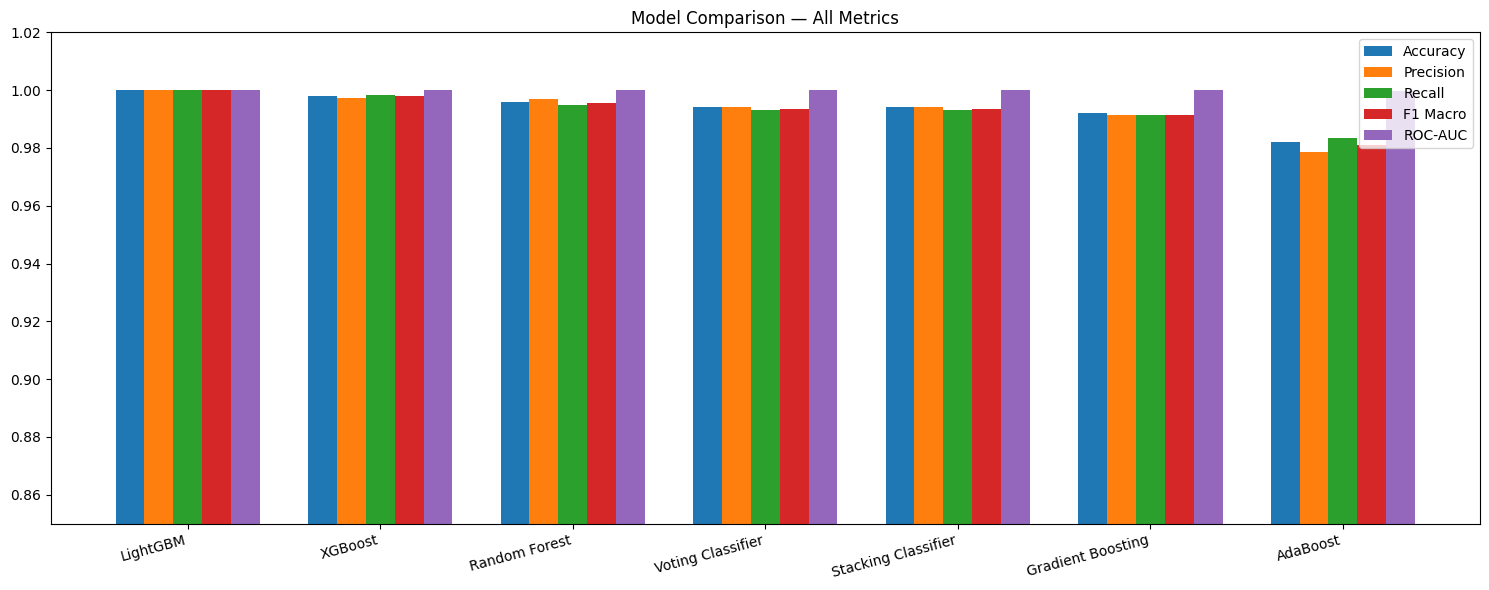

In [7]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Macro", "ROC-AUC"]
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric)

ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df["Model"], rotation=15, ha='right')
ax.set_ylim(0.85, 1.02)
ax.set_title("Model Comparison — All Metrics")
ax.legend()
plt.tight_layout()
plt.savefig('../report/model_comparison.png', dpi=150)
plt.show()

c:\Users\WINDOW 10 PRO\Desktop\CKD-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Model: LightGBM

Classification Report:
              precision    recall  f1-score   support

         ckd       1.00      1.00      1.00       313
      notckd       1.00      1.00      1.00       187

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



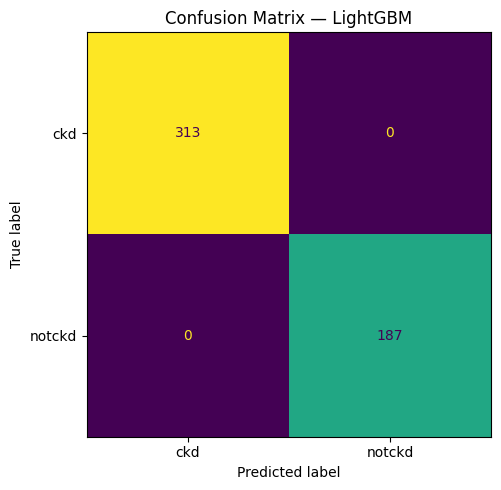

In [8]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"Best Model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, 
    target_names=le_target.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=le_target.classes_,
    ax=ax, colorbar=False
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig('../report/confusion_matrix.png', dpi=150)
plt.show()

In [9]:
joblib.dump(best_pipeline, '../artifacts/final_model.joblib')
print(f"✓ Best model saved: {best_model_name}")
print(f"✓ Saved to: ../artifacts/final_model.joblib")

# Save results
results_df.to_csv('../report/model_results.csv', index=False)
print("✓ Results saved to: ../report/model_results.csv")

✓ Best model saved: LightGBM
✓ Saved to: ../artifacts/final_model.joblib
✓ Results saved to: ../report/model_results.csv


## Results Summary

- Best model selected based on F1 Macro score
- KNNImputer inside Pipeline — no data leakage
- Evaluated on held-out 20% test set
- CV scores confirm generalization